### Build A Basic Chatbot with LangGraph (Graph API)


In [1]:
import sys
print("Current Executable:", sys.executable)
print("Looking for packages in:", sys.path)


Current Executable: c:\YASHIT\AI\langchain1\.venv\Scripts\python.exe
Looking for packages in: ['C:\\Users\\yashit\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\yashit\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'C:\\Users\\yashit\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'C:\\Users\\yashit\\AppData\\Local\\Programs\\Python\\Python312', 'c:\\YASHIT\\AI\\langchain1\\.venv', '', 'c:\\YASHIT\\AI\\langchain1\\.venv\\Lib\\site-packages']


In [2]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


<p>
a <B>TypedDict</B> creates a standard Python dictionary (dict) at runtime. It is not an object.
In Python, regular dictionaries must use square bracket string lookups: state["messages"].
If you want to use dot notation (state.messages), your state blueprint would have to be written as a <B>Pydantic BaseModel</B> instead of a TypedDict.
</p>

In [3]:
class State(TypedDict):
    messages:Annotated[list, add_messages]

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [5]:
from langchain.chat_models import init_chat_model

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
model = init_chat_model(
    model = "google_genai:gemini-3.1-flash-lite"
)

<p>
a <B>TypedDict</B> creates a standard Python dictionary (dict) at runtime. It is not an object.
In Python, regular dictionaries must use square bracket string lookups: state["messages"].
If you want to use dot notation (state.messages), your state blueprint would have to be written as a <B>Pydantic BaseModel</B> instead of a TypedDict.
</p>

In [6]:
def chatbot(state:State):
    return {
        "messages":[model.invoke(state["messages"])]
    }

In [7]:
graph_builder = StateGraph(State)

graph_builder.add_node("llmChatBot", chatbot)

graph_builder.add_edge(START, "llmChatBot")
graph_builder.add_edge("llmChatBot", END)

graph = graph_builder.compile()

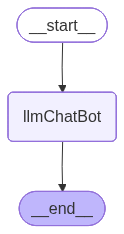

In [8]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
response = graph.invoke({"messages" : "Hi"})
response

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='87feb669-d942-4590-bc87-f9df3d800c7f'),
  AIMessage(content=[{'type': 'text', 'text': 'Hello! How can I help you today?', 'extras': {'signature': 'EjQKMgEMOdbHmqo9NZP7No0czBsKXFIaSq4HmjIKo97fCB4UyknwcORtEnJxXVKH+MXW6IAX'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e6fb2-888a-7202-9df2-f6c69c04afa0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 2, 'output_tokens': 9, 'total_tokens': 11, 'input_token_details': {'cache_read': 0}})]}

### Step1
<ol>
<li>LangGraph spins up a brand-new internal dictionary based on your State blueprint.
<li>It takes your input {"messages": "Hi"} and routes it through the START edge.
<li>Because your messages key is wrapped in Annotated[list, add_messages], LangGraph recognizes add_messages as a specialized reducer function. Instead of overwriting old history, it takes the raw string "Hi", automatically wraps it into a proper HumanMessage(content="Hi") object, and appends it to your state tracker list.
</ol>

<hr>

### Step2
<ol>
<li>Read: Your function looks inside the dictionary using state["messages"]. It pulls out the list containing your HumanMessage.
<li>Compute: It passes that whole list to your LLM via model.invoke(...). The Gemini/OpenAI model reads the history and outputs a raw AIMessage(content="Hello! How can I help you today?").
<li>Return: Your node returns a partial dictionary change: {"messages": [AIMessage(...)]}.
</ol>

###  <h1>It's responsibility of LLM that whenever it receives the response it has to add it in list ?</h1>
It is not the responsibility of the LLM to manage the list, nor does the LLM know anything about your TypedDict. The LLM is completely stateless—it just takes a prompt and returns a single text/message block.

Managing the list and making sure it fits your TypedDict is 100% the responsibility of LangGraph and your code.

### <h1>What if the response doesn't match the TypedDict?</h1> 

<h3>Scenario A: You return a different data type (Python stays quiet, but your code might break later)</h3>

```
def bad_chatbot(state: State):
    return {"messages": [99999]}  # 99999 is NOT a message object!
```
What TypedDict does: Nothing. It ignores it at runtime.

What LangGraph's add_messages does: It will try its best to convert 99999 into a usable message format. However, if it receives something it cannot parse at all, LangGraph's internal code will throw a ValueError or TypeError because its reducer functions expect message-like structures.

<hr>

<h3>Scenario B: You return a completely wrong key name (LangGraph throws an Error)</h3>

If you return a dictionary key that you didn't define in your TypedDict:
```
def broken_chatbot(state: State):
    return {"user_profile_data": "some value"}  # This key is NOT in your State!
```
The moment your node returns this, LangGraph checks the keys against your StateGraph(State) setup. Because "user_profile_data" was never declared in your State blueprint, LangGraph will instantly halt execution and throw an error telling you that you are trying to write to an invalid, unrecognized state key.

### <h1>ChatBot with tools</h1>

In [10]:
from langchain_tavily import TavilySearch
os.environ['TAVILY_API_KEY'] = "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"
tool = TavilySearch(max_results = 2)

In [11]:
def multiply(a:int, b:int):
    """ Multiply two numbers """
    return a * b


In [12]:
tools = [tool, multiply]

In [13]:
model_with_tools = model.bind_tools(tools)

### Visualizing the Tool Calling Loop

```text
               ┌──────────────────────┐
               │   tool_calling_llm   │ <────────────────┐
               └──────────┬───────────┘                  │
                          │                              │
               [add_conditional_edges]                   │
                          │                              │
               Is there a tool_call?                     │
                     /          \                        │
                   YES           NO                      │
                   /              \                      │
                  ▼                ▼                     │
         ┌──────────────┐     ┌──────────┐               │
         │  "tools"     │     │   END    │               │
         │ (ToolNode)   │     └──────────┘               │
         └────────┬─────┘                                │
                  │                                      │
                  └──────────────────────────────────────┘
                   (Executes Python function & loops back)

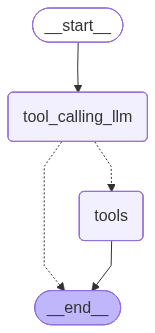

In [14]:
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def tool_calling_llm(state:State):
    return {"messages" : model_with_tools.invoke(state["messages"])}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()


from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

### Summary: Why Tools are Bound to Both LangChain and LangGraph

In a manual LangGraph implementation, tools must be passed to both components because they handle completely different parts of the execution lifecycle:

---

#### 1. LangChain Layer (`model.bind_tools`) — **The Awareness Menu**
* **The Role:** Informs the LLM that the tools exist.
* **How it works:** It converts your Python function definitions into JSON schemas and uploads them to the model's cloud brain.
* **Capabilities:** It allows the LLM to understand *what* tools are available, *when* to use them, and *how* to generate a structured `tool_calls` request string.
* **Limitation:** It **cannot execute** your local Python code.

#### 2. LangGraph Layer (`ToolNode`) — **The Execution Kitchen**
* **The Role:** Actually runs the Python code on your local machine.
* **How it works:** It listens for the `tool_calls` request coming back from the LLM, matches the requested string name against your real Python function array, and executes it.
* **Capabilities:** It runs your local code, intercepts the output, wraps it into a proper `ToolMessage`, and appends it back into your conversational `State`.
* **Limitation:** It cannot tell the LLM *when* or *why* to use a tool.

---

#### 💡 The Core Analogy
* **`model.bind_tools()`** $\rightarrow$ Handing a **Menu** to a restaurant customer (The LLM). They can read it and *order* a dish, but they can't cook it themselves.
* **`ToolNode()`** $\rightarrow$ Handing the **Ingredients and Recipe** to the kitchen chef (LangGraph). They can actually *cook* the dish, but only if the customer selects it from the menu first.

*(Note: If you use the `create_agent()` high-level wrapper, LangGraph automatically handles both of these steps under the hood using a single shared tools array).*

In [15]:
response = graph.invoke({"messages" : "How was the 26th May 2026 Indian Stock Market and what is expected for tomorrow"})
res = response["messages"][-1].content


for m in response['messages']:
    m.pretty_print()

response = graph.invoke({"messages" : "multiply 2 and 3 and then multiply 5 and what is langgraph "})
res = response["messages"][-1].content


for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

How was the 26th May 2026 Indian Stock Market and what is expected for tomorrow
================================== Ai Message ==================================

[]
Tool Calls:
  tavily_search (4c556f60-c99b-4800-b815-87e016a6ba84)
 Call ID: 4c556f60-c99b-4800-b815-87e016a6ba84
  Args:
    query: Indian Stock Market performance May 26 2026
================================= Tool Message =================================
Name: tavily_search

{"query": "Indian Stock Market performance May 26 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://mf.nipponindiaim.com/LearnAndInvest/MarketsForYou/markets-for-you-may-26-2026.html", "title": "Markets For You of 26 May 2026", "content": "[1]Data as o n 22 M ay, 2026. •Indian equity markets rose as hop es for a U.S.-Iran peace deal led to a. •The overall market breadth on BSE was strong with 2,703 scrips advancing. •Asian eq

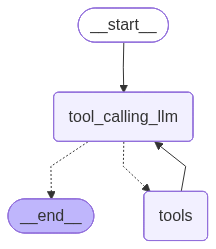

In [16]:
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def tool_calling_llm(state:State):
    return {"messages" : model_with_tools.invoke(state["messages"])}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()


from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
response = graph.invoke({"messages" : "How was the 26th May 2026 Indian Stock Market and what is expected for tomorrow and multiply 2 and 3"})
res = response["messages"][-1].content

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

How was the 26th May 2026 Indian Stock Market and what is expected for tomorrow and multiply 2 and 3
================================== Ai Message ==================================

[]
Tool Calls:
  tavily_search (02e20026-afc6-44ad-aeb4-0a2b3d5013aa)
 Call ID: 02e20026-afc6-44ad-aeb4-0a2b3d5013aa
  Args:
    query: Indian Stock Market performance 26 May 2026
  multiply (214f15c8-7cf8-4bfa-b98e-a29b1332a9e1)
 Call ID: 214f15c8-7cf8-4bfa-b98e-a29b1332a9e1
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "Indian Stock Market performance 26 May 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://hdfcsky.com/news/prime-end-of-the-day-summary-view-on-market-performance-26-may-2026", "title": "Nifty Falls 118 Pts as Rupee Weakens, Oil Prices Rise", "content": "# Prime End of the D

### <h1> Memory

In [20]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = builder.compile(checkpointer = memory)

config = {"configurable":{"thread_id":"user1"}}

response = graph.invoke({"messages":"My name is yashit jain"}, config=config)

response["messages"][-1].content

[{'type': 'text',
  'text': "Hello, Yashit Jain! It's nice to meet you. How can I help you today?",
  'extras': {'signature': 'EjQKMgEMOdbHrJeM/H5SZ9wICDhm7wJ6DR8KCL9lT5uYNPpxV2xXqhPIm2AgN9DCi2tcvVt6'}}]

In [21]:
response = graph.invoke({"messages":"Hey what is my name do you remember ?"}, config=config)

response["messages"][-1].content

[{'type': 'text',
  'text': 'Yes, I remember! Your name is Yashit Jain.',
  'extras': {'signature': 'EjQKMgEMOdbHOvsljLizpwasFa083Fk92YHtSOI473RPbdGuLVlUj/YhrtDEFgzoGGaAk+1q'}}]

<p><b> It is necessary to use config i.e the thread along with memorysaver so that each user's information remain stored

### <H1> Stream Astream (modes = updates , values) </H1>
Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

<li>values : This streams the full state of the graph after each node is called.
<li>updates : This streams updates to the state of the graph after each node is called.

In [27]:
config = {"configurable" : {"thread_id":"1"}}

for chunk in graph.invoke({"messages":["Hi,My name is Krish And I like cricket"]}, config=config, stream_mode="updates"):
    print(chunk["tool_calling_llm"]["messages"].content)

[{'type': 'text', 'text': "Hi Krish! It's nice to meet you again. \n\nI'm definitely getting the message that you're a big cricket fan! How can I help you out today? Are you looking for some stats, interested in a specific player, or do you just want to talk about the sport?", 'extras': {'signature': 'EjQKMgEMOdbHrz2I8QWG5ohjKZSUwWJu42pUYjEtJw5o6m4Oa5XqIcuY/cuEehD5uDfQEFrr'}}]


In [29]:
for chunk in graph.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='047f6172-bbb2-41b6-a823-2320e545140a'), AIMessage(content=[{'type': 'text', 'text': "Hello, Krish! It's nice to meet you.\n\nSince you're a cricket fan, I'm curious—do you have a favorite team or player? Or perhaps you enjoy playing the game yourself?", 'extras': {'signature': 'EjQKMgEMOdbHtnu3TycQWwoBPfMmKboUGNxpQ5onqGkKyqia/E0yAZ9BC/FQqSR7zx61568a'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e6fe6-7b77-7271-9fa8-193780c02453-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1551, 'output_tokens': 44, 'total_tokens': 1595, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='6b41fc18-5761-4035-afe7-1261e

In [34]:
config = {"configurable":{"thread_id":"2"}}

async for event in graph.astream_events({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi,My name is Krish And I like cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e6fec-bc1b-76d3-98d3-8eb06b0efa2d', 'metadata': {'thread_id': '2', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_stream', 'run_id': '019e6fec-bc1b-76d3-98d3-8eb06b0efa2d', 'name': 'LangGraph', 'tags': [], 'metadata': {'thread_id': '2', 'ls_integration': 'langgraph'}, 'data': {'chunk': {'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='61a341dc-35a1-440d-b2e1-45e245372197')]}}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='61a341dc-35a1-440d-b2e1-45e245372197')]}}, 'name': 'tool_calling_llm', 'tags': ['graph:step:1'], 'run_id': '019e6fec-bc23-7ac1-b869-e0bbb6ed9fe6', 'metadata': {'thread_id': '2', 'ls_i